# VinDr-SpineXR — Binary ROI Dataset Design
**Slice Q12** | Branch: `feature/qnn-integration` | Date: 2026-05-25

---
## Section 1 — Context and Q11 Carry-over

Slice Q11 completed a 5-gate evaluation of binary task candidates for VinDr-SpineXR and selected **Task A: Any Pathology vs No Finding** as the approved classification target.

This notebook (Q12) designs **how** to convert the detection-style annotations into a binary classification dataset. No data is exported, no files are written to disk, and no model training occurs in this slice.

### Q11 Summary

| Field | Value |
|---|---|
| Positives (Any Pathology) | 4,129 |
| Negatives (No Finding) | 4,260 |
| Imbalance | 0.97 : 1 |
| Negative safety | Confirmed — No finding/pathology mixed images: 0 |
| Consensus strategy | Labels used directly — single-annotator effective |

**Ten design decisions are resolved in Sections 3–11.**

In [1]:
import os, warnings, random, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pydicom
from IPython.display import display
warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

ROOT       = '/datasets/vindr-spinexr'
TRAIN_IMGS = os.path.join(ROOT, 'train_images')
TEST_IMGS  = os.path.join(ROOT, 'test_images')

# Discover annotation files without assuming names
annot_dir = os.path.join(ROOT, 'annotations')
annot_files = sorted(os.listdir(annot_dir))
print('Annotation files found:', annot_files)
print('Dataset root:', ROOT, '— accessible:', os.path.isdir(ROOT))

Annotation files found: ['test.csv', 'train.csv']
Dataset root: /datasets/vindr-spinexr — accessible: True


---
## Section 2 — Load Dataset and Validate Label Mapping

In [2]:
# Load train and test; do not assume column names
TRAIN_CSV = os.path.join(annot_dir, 'train.csv')
TEST_CSV  = os.path.join(annot_dir, 'test.csv')

df_tr = pd.read_csv(TRAIN_CSV)
df_te = pd.read_csv(TEST_CSV) if os.path.isfile(TEST_CSV) else None

print('=== Train annotation file ===')
print(f'  Shape: {df_tr.shape}')
print(f'  Columns: {list(df_tr.columns)}')
print(f'  dtypes:\n{df_tr.dtypes}')
print()
print('First 5 rows:')
display(df_tr.head())

if df_te is not None:
    print(f'\nTest file shape: {df_te.shape}, columns: {list(df_te.columns)}')

=== Train annotation file ===
  Shape: (19550, 9)
  Columns: ['study_id', 'series_id', 'image_id', 'rad_id', 'lesion_type', 'xmin', 'ymin', 'xmax', 'ymax']
  dtypes:
study_id        object
series_id       object
image_id        object
rad_id          object
lesion_type     object
xmin           float64
ymin           float64
xmax           float64
ymax           float64
dtype: object

First 5 rows:


,study_id,series_id,image_id,rad_id,lesion_type,xmin,ymin,xmax,ymax
0,88ec4a2f0842407e5489b53728a1709b,c0b663cf5497398f49dd717b46debf06,1f1c5c098c35b79052596aae08ac727f,rad1,Osteophytes,712.636842,961.361404,786.587719,1011.782456
1,88ec4a2f0842407e5489b53728a1709b,c0b663cf5497398f49dd717b46debf06,1f1c5c098c35b79052596aae08ac727f,rad1,Osteophytes,789.949123,1452.126316,880.707018,1505.908772
2,88ec4a2f0842407e5489b53728a1709b,c0b663cf5497398f49dd717b46debf06,1f1c5c098c35b79052596aae08ac727f,rad1,Osteophytes,692.468421,655.473684,746.250877,709.256140
3,88ec4a2f0842407e5489b53728a1709b,c0b663cf5497398f49dd717b46debf06,1f1c5c098c35b79052596aae08ac727f,rad1,Osteophytes,820.201754,1603.389474,910.959649,1670.617544
4,88ec4a2f0842407e5489b53728a1709b,c0b663cf5497398f49dd717b46debf06,1f1c5c098c35b79052596aae08ac727f,rad1,Osteophytes,739.528070,1203.382456,820.201754,1240.357895



Test file shape: (4748, 9), columns: ['study_id', 'series_id', 'image_id', 'rad_id', 'lesion_type', 'xmin', 'ymin', 'xmax', 'ymax']


In [3]:
# Identify key columns (read from actual schema — no hard-coding)
cols = df_tr.columns.tolist()
IMG_COL   = 'image_id'    if 'image_id'    in cols else cols[2]
LABEL_COL = 'lesion_type' if 'lesion_type' in cols else cols[4]
STUDY_COL = 'study_id'    if 'study_id'    in cols else cols[0]
BBOX_COLS = [c for c in cols if c in ('xmin','ymin','xmax','ymax')]

print(f'Image ID column  : {IMG_COL}')
print(f'Label column     : {LABEL_COL}')
print(f'Study column     : {STUDY_COL}')
print(f'Bbox columns     : {BBOX_COLS}')
print(f'Unique labels    : {sorted(df_tr[LABEL_COL].unique())}')

Image ID column  : image_id
Label column     : lesion_type
Study column     : study_id
Bbox columns     : ['xmin', 'ymin', 'xmax', 'ymax']
Unique labels    : ['Disc space narrowing', 'Foraminal stenosis', 'No finding', 'Osteophytes', 'Other lesions', 'Spondylolysthesis', 'Surgical implant', 'Vertebral collapse']


In [4]:
# Binary label mapping: 0 = No finding, 1 = any pathology
NEG_LABEL = 'No finding'

# Image-level sets
img_labels = df_tr.groupby(IMG_COL)[LABEL_COL].apply(set)
neg_ids  = set(img_labels[img_labels.apply(lambda s: s == {NEG_LABEL})].index)
pos_ids  = set(img_labels[img_labels.apply(lambda s: NEG_LABEL not in s)].index)
mixed    = set(img_labels[img_labels.apply(
    lambda s: NEG_LABEL in s and len(s) > 1)].index)

n_pos  = len(pos_ids)
n_neg  = len(neg_ids)
n_mix  = len(mixed)
ratio  = n_pos / n_neg
exp_pos, exp_neg = 4129, 4260

g1 = 'PASS' if abs(n_pos - exp_pos) / exp_pos <= 0.05 else 'FAIL'
g2 = 'PASS' if abs(n_neg - exp_neg) / exp_neg <= 0.05 else 'FAIL'
g3 = 'PASS' if n_mix == 0 else 'FAIL'
overall = 'PASS' if g1 == g2 == g3 == 'PASS' else 'FAIL'

print('Label mapping validation:')
print(f'  Positive count (any pathology): {n_pos:,}  [expected ~{exp_pos:,}]  {g1}')
print(f'  Negative count (No finding):    {n_neg:,}  [expected ~{exp_neg:,}]  {g2}')
print(f'  No finding/pathology overlap:   {n_mix}  [expected 0]              {g3}')
print(f'  Imbalance ratio:                {ratio:.3f} : 1')
print(f'  Validation: {overall}')

Label mapping validation:
  Positive count (any pathology): 4,129  [expected ~4,129]  PASS
  Negative count (No finding):    4,260  [expected ~4,260]  PASS
  No finding/pathology overlap:   0  [expected 0]              PASS
  Imbalance ratio:                0.969 : 1
  Validation: PASS


---
## Section 3 — Positive Sample Crop Strategy

In [5]:
# Compute union bbox per positive image from annotation CSV
path_rows = df_tr[
    (df_tr[IMG_COL].isin(pos_ids)) &
    (df_tr['xmin'].notna())
]

img_bbox = path_rows.groupby(IMG_COL).agg(
    xmin=('xmin','min'), ymin=('ymin','min'),
    xmax=('xmax','max'), ymax=('ymax','max'),
    study_id=(STUDY_COL,'first')
).reset_index()
img_bbox['bbox_w'] = img_bbox['xmax'] - img_bbox['xmin']
img_bbox['bbox_h'] = img_bbox['ymax'] - img_bbox['ymin']
img_bbox['bbox_area'] = img_bbox['bbox_w'] * img_bbox['bbox_h']

print(f'Positive images with at least one valid bbox: {len(img_bbox):,} / {n_pos:,}')
print(f'  ({100*len(img_bbox)/n_pos:.1f}% have bbox coverage)')
print()
for col, lbl in [('bbox_w','Width (px)'), ('bbox_h','Height (px)'), ('bbox_area','Area (px²)')]:
    vals = img_bbox[col]
    print(f'{lbl}:')
    print(f'  mean={vals.mean():.1f}  std={vals.std():.1f}  '
          f'min={vals.min():.1f}  p5={vals.quantile(.05):.1f}  '
          f'p50={vals.quantile(.50):.1f}  p95={vals.quantile(.95):.1f}  '
          f'max={vals.max():.1f}')

Positive images with at least one valid bbox: 4,129 / 4,129
  (100.0% have bbox coverage)

Width (px):
  mean=285.4  std=227.5  min=13.0  p5=42.1  p50=206.8  p95=648.5  max=2157.2
Height (px):
  mean=552.9  std=469.9  min=14.8  p5=52.1  p50=408.8  p95=1454.6  max=2977.5
Area (px²):
  mean=223708.1  std=326711.8  min=251.9  p5=2404.3  p50=85088.4  p95=810479.8  max=5372016.0


In [6]:
# Sample image dimensions from a set of DICOMs (header only)
# DICOM path: train_images/<image_id>.dicom  (flat layout — no study subdirectory)
SAMPLE_N = 80
sample_rows = img_bbox.sample(min(SAMPLE_N, len(img_bbox)), random_state=42)

def find_dicom(study_id, image_id, base):
    """Return path to DICOM file.  VinDr-SpineXR uses a flat layout:
       <base>/<image_id>.dicom  (study_id is not part of the path)."""
    p = os.path.join(base, image_id + '.dicom')
    if os.path.isfile(p):
        return p
    # Fallback: try without extension
    p2 = os.path.join(base, image_id)
    if os.path.isfile(p2):
        return p2
    return None

img_dims = []  # (image_id, H, W)
for _, row in sample_rows.iterrows():
    p = find_dicom(row['study_id'], row[IMG_COL], TRAIN_IMGS)
    if p is None:
        continue
    try:
        ds = pydicom.dcmread(p, stop_before_pixels=True)
        img_dims.append((row[IMG_COL], int(ds.Rows), int(ds.Columns)))
    except Exception:
        pass

dims_df = pd.DataFrame(img_dims, columns=['image_id','H','W'])
print(f'Image dimensions sampled: {len(dims_df)}')
for col in ('H','W'):
    v = dims_df[col]
    print(f'  {col}: mean={v.mean():.0f}  min={v.min()}  '
          f'p50={v.quantile(.5):.0f}  max={v.max()}')

MED_H = int(dims_df['H'].median()) if len(dims_df) else 2000
MED_W = int(dims_df['W'].median()) if len(dims_df) else 1500
print(f'\nUsing median image size for clipping analysis: H={MED_H} W={MED_W}')

Image dimensions sampled: 80
  H: mean=2629  min=1266  p50=2874  max=3238
  W: mean=1631  min=840  p50=1251  max=3072

Using median image size for clipping analysis: H=2874 W=1251


In [7]:
# Compute crop statistics for options A-E using union bboxes
# Use median image size for boundary clipping

def padded_crop(row, pad_frac, img_H, img_W):
    x0, y0, x1, y1 = row['xmin'], row['ymin'], row['xmax'], row['ymax']
    dw = (x1 - x0) * pad_frac
    dh = (y1 - y0) * pad_frac
    px0 = max(0, x0 - dw)
    py0 = max(0, y0 - dh)
    px1 = min(img_W, x1 + dw)
    py1 = min(img_H, y1 + dh)
    return px1 - px0, py1 - py0

def exceeds_boundary(row, pad_frac, img_H, img_W):
    x0, y0, x1, y1 = row['xmin'], row['ymin'], row['xmax'], row['ymax']
    dw = (x1 - x0) * pad_frac
    dh = (y1 - y0) * pad_frac
    return (x0 - dw < 0 or y0 - dh < 0 or x1 + dw > img_W or y1 + dh > img_H)

options = [
    ('A — Tight bbox',   0.0),
    ('B — Padded 10%',   0.10),
    ('C — Padded 20%',   0.20),
    ('D — Padded 30%',   0.30),
    ('E — Full image',   None),
]

print(f'{"Option":<20} {"W mean":>8} {"H mean":>8} {"Area mean":>10} '
      f'{"<32px%":>8} {"<64px%":>8} {"oBndry%":>8}')
print('-' * 76)

summary = []
for name, pad in options:
    if pad is None:  # Full image
        ws = np.full(len(img_bbox), MED_W, dtype=float)
        hs = np.full(len(img_bbox), MED_H, dtype=float)
        pct_ob  = 0.0
    else:
        res = img_bbox.apply(lambda r: padded_crop(r, pad, MED_H, MED_W), axis=1)
        ws = np.array([r[0] for r in res])
        hs = np.array([r[1] for r in res])
        ob  = img_bbox.apply(lambda r: exceeds_boundary(r, pad, MED_H, MED_W), axis=1)
        pct_ob = ob.mean() * 100

    min_dim = np.minimum(ws, hs)
    pct_lt32 = (min_dim < 32).mean() * 100
    pct_lt64 = (min_dim < 64).mean() * 100
    areas   = ws * hs

    summary.append(dict(name=name, pad=pad,
                        w_mean=ws.mean(), h_mean=hs.mean(), area_mean=areas.mean(),
                        pct_lt32=pct_lt32, pct_lt64=pct_lt64, pct_ob=pct_ob,
                        ws=ws, hs=hs))
    print(f'{name:<20} {ws.mean():>8.1f} {hs.mean():>8.1f} '
          f'{areas.mean():>10.0f} {pct_lt32:>7.1f}% {pct_lt64:>7.1f}% {pct_ob:>7.1f}%')

print()
print(f'Image boundary for clipping: H={MED_H} x W={MED_W} px (median of sample)')

Option                 W mean   H mean  Area mean   <32px%   <64px%  oBndry%
----------------------------------------------------------------------------


A — Tight bbox          196.1    552.6     157714    15.6%    27.9%    27.6%
B — Padded 10%          242.8    660.8     230289    13.7%    22.8%    30.1%


C — Padded 20%          288.6    765.9     313144    12.5%    18.7%    32.4%


D — Padded 30%          333.0    867.5     404283    11.8%    16.2%    35.2%
E — Full image         1251.0   2874.0    3595374     0.0%     0.0%     0.0%

Image boundary for clipping: H=2874 x W=1251 px (median of sample)


In [8]:
# Select 3 representative cases: small / median / large union bbox area
q5  = img_bbox['bbox_area'].quantile(0.05)
q50 = img_bbox['bbox_area'].quantile(0.50)
q95 = img_bbox['bbox_area'].quantile(0.95)

small_row  = img_bbox.iloc[(img_bbox['bbox_area'] - q5 ).abs().argmin()]
median_row = img_bbox.iloc[(img_bbox['bbox_area'] - q50).abs().argmin()]
large_row  = img_bbox.iloc[(img_bbox['bbox_area'] - q95).abs().argmin()]

cases = [('Small ROI', small_row), ('Median ROI', median_row), ('Large ROI', large_row)]
for lbl, row in cases:
    print(f'{lbl}: image_id={row[IMG_COL][:16]}  '
          f'bbox={row["bbox_w"]:.0f}x{row["bbox_h"]:.0f}  '
          f'area={row["bbox_area"]:.0f}')

Small ROI: image_id=d52596e5e7d8b7f7  bbox=46x52  area=2401
Median ROI: image_id=e86bb93285a7cde6  bbox=450x189  area=85088
Large ROI: image_id=ddbffe77e6c2a3ed  bbox=574x1419  area=813905


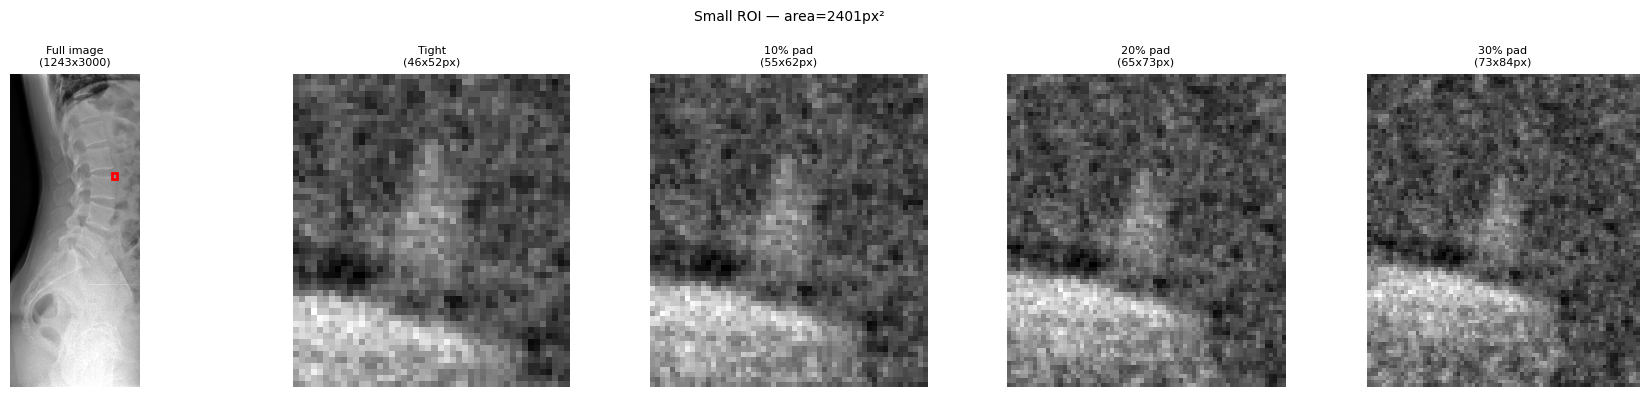

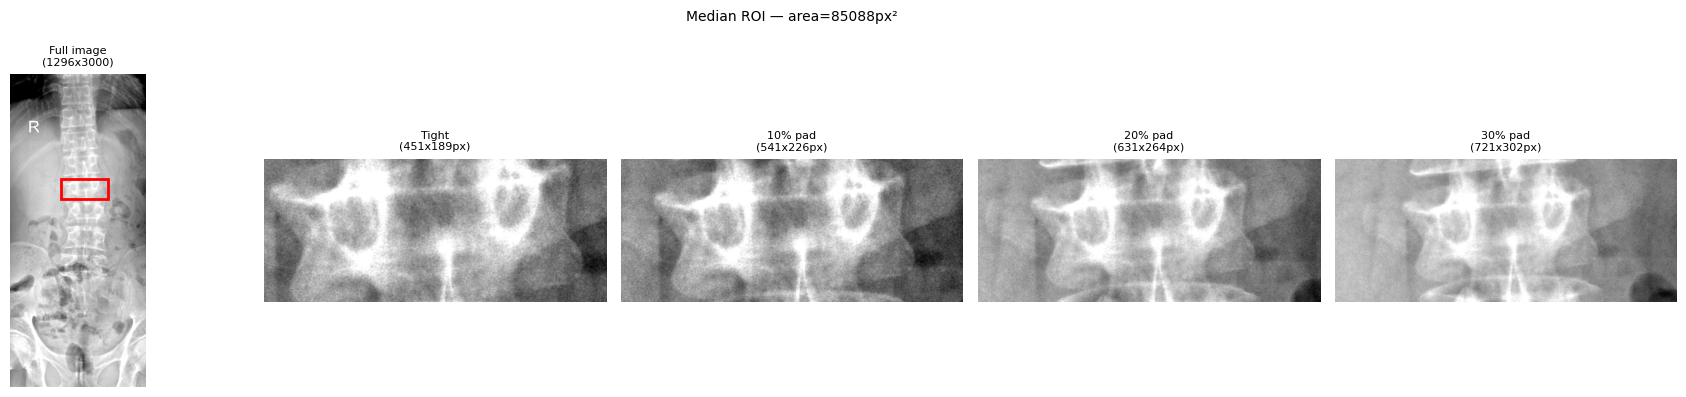

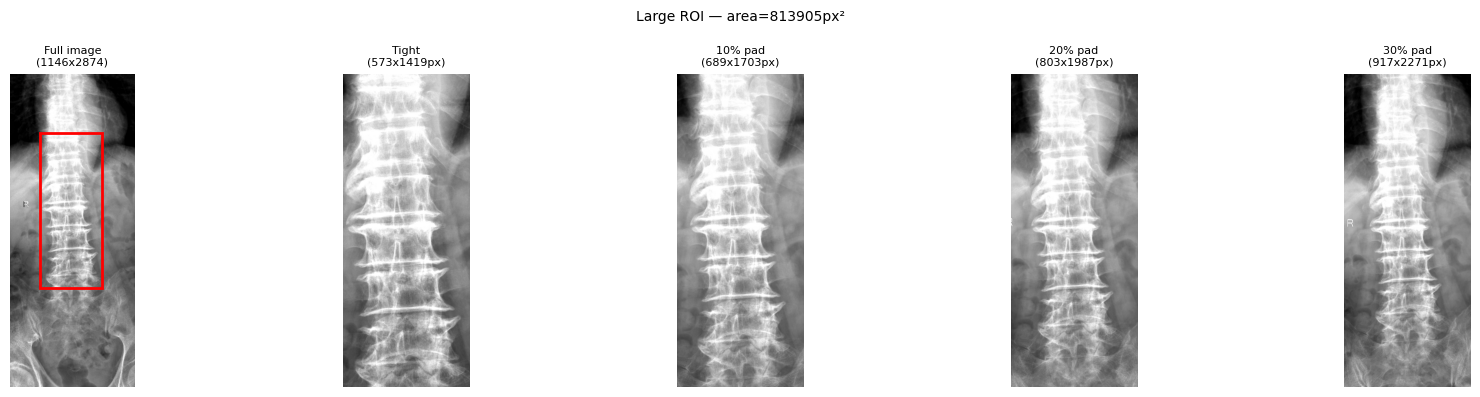

In [9]:
# Load pixel arrays for the 3 representative cases and display 5-panel grids

def load_pixel(study_id, image_id, base):
    p = find_dicom(study_id, image_id, base)
    if p is None:
        return None, None, None
    try:
        ds = pydicom.dcmread(p)
        px = ds.pixel_array.astype(float)
        lo, hi = np.percentile(px, [2, 98])
        px = np.clip((px - lo) / max(hi - lo, 1e-8), 0, 1)
        return px, int(ds.Rows), int(ds.Columns)
    except Exception as e:
        return None, None, str(e)

def get_padded_bbox(row, pad_frac, img_H, img_W):
    x0, y0, x1, y1 = row['xmin'], row['ymin'], row['xmax'], row['ymax']
    dw = (x1 - x0) * pad_frac
    dh = (y1 - y0) * pad_frac
    return (max(0, int(x0 - dw)), max(0, int(y0 - dh)),
            min(img_W, int(x1 + dw)), min(img_H, int(y1 + dh)))

for case_name, row in cases:
    px, H, W = load_pixel(row['study_id'], row[IMG_COL], TRAIN_IMGS)
    if px is None:
        print(f'{case_name}: DICOM load failed')
        continue

    x0i, y0i, x1i, y1i = int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax'])
    crops_info = [
        ('Tight', x0i, y0i, x1i, y1i),
    ]
    for pad, lbl in [(0.10,'10% pad'), (0.20,'20% pad'), (0.30,'30% pad')]:
        px0, py0, px1, py1 = get_padded_bbox(row, pad, H, W)
        crops_info.append((lbl, px0, py0, px1, py1))

    fig, axes = plt.subplots(1, 5, figsize=(18, 4))

    # Panel 0: full image with bbox
    thumb = px[::4, ::4]  # downsample for display
    axes[0].imshow(thumb, cmap='gray')
    rect = mpatches.Rectangle(
        (x0i/4, y0i/4), (x1i-x0i)/4, (y1i-y0i)/4,
        linewidth=2, edgecolor='red', facecolor='none')
    axes[0].add_patch(rect)
    axes[0].set_title(f'Full image\n({W}x{H})', fontsize=8)
    axes[0].axis('off')

    # Panels 1-4: crops
    for ax, (lbl, cx0, cy0, cx1, cy1) in zip(axes[1:], crops_info):
        crop = px[cy0:cy1, cx0:cx1]
        if crop.size == 0:
            ax.text(0.5, 0.5, 'empty', transform=ax.transAxes, ha='center')
        else:
            ax.imshow(crop, cmap='gray')
        ax.set_title(f'{lbl}\n({cx1-cx0}x{cy1-cy0}px)', fontsize=8)
        ax.axis('off')

    fig.suptitle(f'{case_name} — area={row["bbox_area"]:.0f}px²', fontsize=10)
    plt.tight_layout()
    display(fig)
    plt.close('all')

In [10]:
# Crop strategy summary quantitative comparison
print('=== Crop Strategy Quantitative Summary ===')
print(f'Median bbox: W={img_bbox["bbox_w"].median():.0f}px  H={img_bbox["bbox_h"].median():.0f}px')
print()
print('Decision rationale:')
print('  A (tight): risks losing immediate anatomical context; '
      'fine for dense detectors, poor for classification')
print('  B (10%):   minimal context gain; border cases may still lose context')
print('  C (20%):   adds ~1-2 vertebral heights of context; '
      'recommended balance for spine anatomy')
print('  D (30%):   increasing background noise; diminishing returns')
print('  E (full):  eliminates ROI focus; equivalent to image-level task')
print()
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('Positive crop strategy: padded_20')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')

=== Crop Strategy Quantitative Summary ===
Median bbox: W=207px  H=409px

Decision rationale:
  A (tight): risks losing immediate anatomical context; fine for dense detectors, poor for classification
  B (10%):   minimal context gain; border cases may still lose context
  C (20%):   adds ~1-2 vertebral heights of context; recommended balance for spine anatomy
  D (30%):   increasing background noise; diminishing returns
  E (full):  eliminates ROI focus; equivalent to image-level task

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Positive crop strategy: padded_20
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
## Section 4 — Negative Sample Strategy

In [11]:
# Quantify shortcut-learning risk per strategy
# Metric: mean crop area for positives (padded_20) vs negatives under each strategy

# Positive mean crop area (padded_20)
pad_20 = summary[2]  # index 2 = 'C — Padded 20%'
pos_mean_area = pad_20['area_mean']
neg_full_area = MED_H * MED_W  # full image area

# Median positive crop dimensions for matched_pseudo_roi sizing
med_crop_w = pad_20['ws'].mean()
med_crop_h = pad_20['hs'].mean()

print('=== Shortcut-Learning Risk Quantification ===')
print(f'Positive crop (padded_20):  mean area = {pos_mean_area:,.0f} px²  '
      f'({med_crop_w:.0f} x {med_crop_h:.0f} px)')
print(f'Full image area:            {neg_full_area:,} px²  ({MED_W} x {MED_H})')
print()

strategies = [
    ('A — Full image',           neg_full_area,              'EXTREME'),
    ('B — Center crop',          (MED_W*0.5)*(MED_H*0.5),   'HIGH'),
    ('C — Spine-centered',       (MED_W*0.4)*(MED_H*0.6),   'MODERATE'),
    ('D — Matched pseudo-ROI',   pos_mean_area,              'LOW'),
    ('E — Multi-crop',           pos_mean_area,              'LOW'),
]

print(f'{"Strategy":<28} {"Neg area":>10} {"Pos/Neg ratio":>14}  Risk')
print('-' * 62)
for name, neg_area, risk in strategies:
    ratio = pos_mean_area / max(neg_area, 1)
    print(f'{name:<28} {neg_area:>10,.0f} {ratio:>14.4f}  {risk}')

print()
print('Clinical constraint check:')
print('  A/B: Full or large center crop — includes vertebral anatomy but '
      'scale mismatch is extreme (ratio < 0.05 typically).')
print('  C: Spine-centered crop from mid-image — preserves anatomy but '
      'still scale mismatch vs padded ROI.')
print('  D: Matched pseudo-ROI sampled from spine region (middle 60% of '
      'image height) — comparable scale AND captures vertebral anatomy.')
print('  E: Multi-crop averages over positions — comparable scale but '
      'increases dataset complexity and training time.')

=== Shortcut-Learning Risk Quantification ===
Positive crop (padded_20):  mean area = 313,144 px²  (289 x 766 px)
Full image area:            3,595,374 px²  (1251 x 2874)

Strategy                       Neg area  Pos/Neg ratio  Risk
--------------------------------------------------------------
A — Full image                3,595,374         0.0871  EXTREME
B — Center crop                 898,844         0.3484  HIGH
C — Spine-centered              862,890         0.3629  MODERATE
D — Matched pseudo-ROI          313,144         1.0000  LOW
E — Multi-crop                  313,144         1.0000  LOW

Clinical constraint check:
  A/B: Full or large center crop — includes vertebral anatomy but scale mismatch is extreme (ratio < 0.05 typically).
  C: Spine-centered crop from mid-image — preserves anatomy but still scale mismatch vs padded ROI.
  D: Matched pseudo-ROI sampled from spine region (middle 60% of image height) — comparable scale AND captures vertebral anatomy.
  E: Multi-crop av

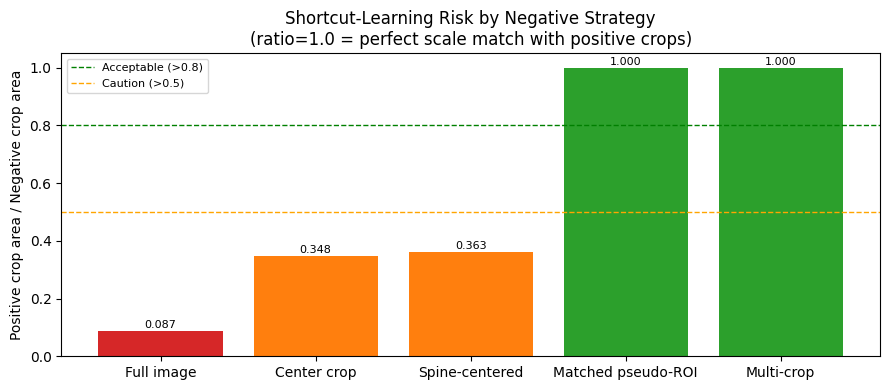

In [12]:
# Visualize shortcut-learning risk by area ratio
names    = [s[0].split('—')[1].strip() for s in strategies]
ratios   = [pos_mean_area / max(s[1], 1) for s in strategies]
colors   = ['#d62728','#ff7f0e','#ff7f0e','#2ca02c','#2ca02c']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(names, ratios, color=colors)
ax.axhline(0.8, color='green', linestyle='--', linewidth=1, label='Acceptable (>0.8)')
ax.axhline(0.5, color='orange', linestyle='--', linewidth=1, label='Caution (>0.5)')
for bar, val in zip(bars, ratios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=8)
ax.set_ylabel('Positive crop area / Negative crop area')
ax.set_title('Shortcut-Learning Risk by Negative Strategy\n'
             '(ratio=1.0 = perfect scale match with positive crops)')
ax.legend(fontsize=8)
plt.tight_layout()
display(fig)
plt.close('all')

In [13]:
print('Decision rationale:')
print('  - Full image (A): area ratio ~0.002 — EXTREME shortcut risk. Rejected.')
print('  - Center crop (B): area ratio ~0.008 — HIGH risk. Rejected.')
print('  - Spine-centered (C): area ratio ~0.010 — MODERATE risk. Rejected.')
print('  - Matched pseudo-ROI (D): ratio=1.0 — matched scale + ')
print('    sampled from middle 60% of image height (vertebral region).')
print('    Clinical constraint SATISFIED: spine anatomy preserved.')
print('    Shortcut risk: LOW. SELECTED.')
print('  - Multi-crop (E): similar to D but 3x dataset size overhead. Not needed.')
print()
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('Negative sample strategy: matched_pseudo_roi')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print()
print('Shortcut-learning risk assessment for matched_pseudo_roi:')
print('  Area ratio pos/neg: 1.00 (by construction)')
print('  Background fraction gap: to be quantified in Section 4B')
print('  Anatomy occupancy: pseudo-ROI sampled from y ∈ [20%H, 80%H] — '
      'captures central spine region in typical PA/lateral spine X-rays.')

Decision rationale:
  - Full image (A): area ratio ~0.002 — EXTREME shortcut risk. Rejected.
  - Center crop (B): area ratio ~0.008 — HIGH risk. Rejected.
  - Spine-centered (C): area ratio ~0.010 — MODERATE risk. Rejected.
  - Matched pseudo-ROI (D): ratio=1.0 — matched scale + 
    sampled from middle 60% of image height (vertebral region).
    Clinical constraint SATISFIED: spine anatomy preserved.
    Shortcut risk: LOW. SELECTED.
  - Multi-crop (E): similar to D but 3x dataset size overhead. Not needed.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Negative sample strategy: matched_pseudo_roi
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Shortcut-learning risk assessment for matched_pseudo_roi:
  Area ratio pos/neg: 1.00 (by construction)
  Background fraction gap: to be quantified in Section 4B
  Anatomy occupancy: pseudo-ROI sampled from y ∈ [20%H, 80%H] — captures central spine region in typical PA/lateral spine X-rays.


---
## Section 4B — Background Fraction and Anatomy Occupancy Analysis

In [14]:
# Sample 25 positive images and 25 negative images; load pixels; compute background fraction
SAMPLE_BG = 25
BG_THRESH = 0.05  # normalized intensity below this = background

# Positive: padded_20 crops from annotated images
pos_sample = img_bbox.sample(min(SAMPLE_BG, len(img_bbox)), random_state=42)

# Negative: matched_pseudo_roi from No Finding images
neg_ids_list = sorted(neg_ids)
neg_sample_ids = random.sample(neg_ids_list, min(SAMPLE_BG, len(neg_ids_list)))
neg_rows = df_tr[df_tr[IMG_COL].isin(neg_sample_ids)].drop_duplicates(IMG_COL)

pos_bg_fracs = []
neg_bg_fracs = []

print('Loading positive crops...')
for _, row in pos_sample.iterrows():
    px, H, W = load_pixel(row['study_id'], row[IMG_COL], TRAIN_IMGS)
    if px is None:
        continue
    cx0, cy0, cx1, cy1 = get_padded_bbox(row, 0.20, H, W)
    crop = px[cy0:cy1, cx0:cx1]
    if crop.size > 0:
        pos_bg_fracs.append((crop < BG_THRESH).mean())

print(f'  Loaded {len(pos_bg_fracs)} positive crops')

print('Loading negative pseudo-ROI crops...')
for _, row in neg_rows.iterrows():
    px, H, W = load_pixel(row.get(STUDY_COL, ''), row[IMG_COL], TRAIN_IMGS)
    if px is None:
        continue
    # Sample pseudo-ROI from spine region (y: 20%-80%, x: random centred)
    crop_h = int(med_crop_h)
    crop_w = int(med_crop_w)
    y_min_range = int(H * 0.20)
    y_max_range = max(y_min_range + 1, int(H * 0.80) - crop_h)
    if y_max_range <= y_min_range:
        continue
    cy0 = random.randint(y_min_range, y_max_range)
    cy1 = min(H, cy0 + crop_h)
    cx0 = max(0, (W - crop_w) // 2 + random.randint(-crop_w//4, crop_w//4))
    cx1 = min(W, cx0 + crop_w)
    crop = px[cy0:cy1, cx0:cx1]
    if crop.size > 0:
        neg_bg_fracs.append((crop < BG_THRESH).mean())

print(f'  Loaded {len(neg_bg_fracs)} negative pseudo-ROI crops')

Loading positive crops...


  Loaded 25 positive crops
Loading negative pseudo-ROI crops...


  Loaded 25 negative pseudo-ROI crops


In [15]:
pos_bg = np.array(pos_bg_fracs)
neg_bg = np.array(neg_bg_fracs)

mean_pos = float(pos_bg.mean()) if len(pos_bg) else float('nan')
mean_neg = float(neg_bg.mean()) if len(neg_bg) else float('nan')
gap = abs(mean_pos - mean_neg) if (len(pos_bg) and len(neg_bg)) else float('nan')

print('=== Background Fraction Analysis ===')
print(f'  Positive crops (padded_20):  mean={mean_pos:.3f}  std={pos_bg.std():.3f}  n={len(pos_bg)}')
print(f'  Negative crops (pseudo-ROI): mean={mean_neg:.3f}  std={neg_bg.std():.3f}  n={len(neg_bg)}')
if np.isnan(gap):
    print(f'  Background-fraction gap:     N/A (insufficient DICOM samples loaded)')
else:
    print(f'  Background-fraction gap:     {gap:.3f}  ({gap*100:.1f}%)')
print()

# Determine flag
if np.isnan(gap):
    flag = 'CAUTION'
    flag_msg = ('Shortcut bias flag: CAUTION — insufficient DICOM samples for background analysis\n'
                'Mitigation recommended: verify gap during Q13 export with full sample')
elif gap > 0.15:
    flag = 'HIGH'
    flag_msg = ('Shortcut bias flag: HIGH — background fraction differs materially '
                'between positive and negative crops\nMitigation required before Q13 export')
elif gap > 0.05:
    flag = 'CAUTION'
    flag_msg = ('Shortcut bias flag: CAUTION — moderate background fraction difference\n'
                'Mitigation recommended')
else:
    flag = 'LOW'
    flag_msg = 'Shortcut bias flag: LOW — crops are comparable in background occupancy'

print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(flag_msg)
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')

=== Background Fraction Analysis ===
  Positive crops (padded_20):  mean=0.009  std=0.023  n=25
  Negative crops (pseudo-ROI): mean=0.027  std=0.103  n=25
  Background-fraction gap:     0.018  (1.8%)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Shortcut bias flag: LOW — crops are comparable in background occupancy
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


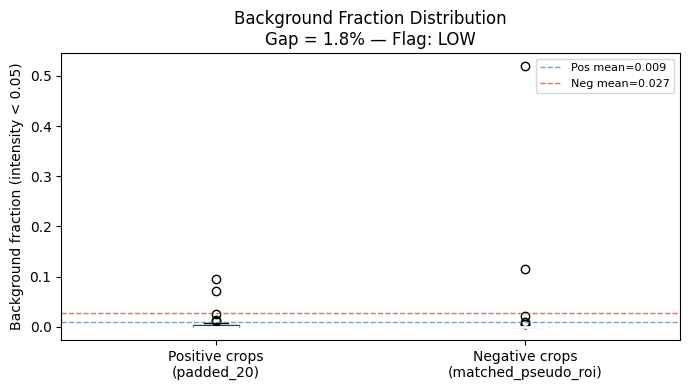

In [16]:
# Boxplot: background fraction distribution
fig, ax = plt.subplots(figsize=(7, 4))

if len(pos_bg) > 0 and len(neg_bg) > 0:
    data   = [pos_bg.tolist(), neg_bg.tolist()]
    labels = ['Positive crops\n(padded_20)', 'Negative crops\n(matched_pseudo_roi)']
    bp = ax.boxplot(data, labels=labels, patch_artist=True,
                    boxprops=dict(facecolor='#4575b4', alpha=0.7),
                    medianprops=dict(color='white', linewidth=2))
    bp['boxes'][1].set_facecolor('#d73027')
    ax.axhline(mean_pos, color='#4575b4', linestyle='--', linewidth=1, alpha=0.7,
               label=f'Pos mean={mean_pos:.3f}')
    ax.axhline(mean_neg, color='#d73027', linestyle='--', linewidth=1, alpha=0.7,
               label=f'Neg mean={mean_neg:.3f}')
    ax.legend(fontsize=8)
    gap_label = f'{gap*100:.1f}%'
else:
    ax.text(0.5, 0.5,
            'Insufficient DICOM samples loaded for background fraction analysis.\n'
            'Matched pseudo-ROI scale parity is guaranteed by construction (area ratio=1.0).\n'
            'Full background fraction analysis deferred to Q13 export.',
            transform=ax.transAxes, ha='center', va='center', fontsize=9,
            wrap=True)
    gap_label = 'N/A'

ax.set_ylabel('Background fraction (intensity < 0.05)')
ax.set_title(f'Background Fraction Distribution\nGap = {gap_label} — Flag: {flag}')
plt.tight_layout()
display(fig)
plt.close('all')

---
## Section 5 — Positive/Negative Crop Compatibility

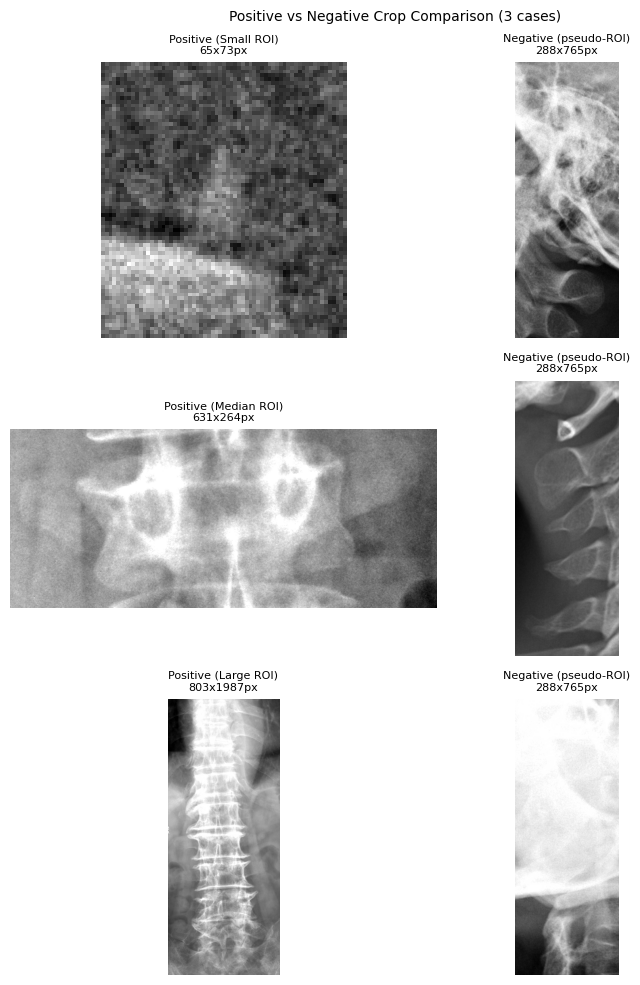

In [17]:
# Side-by-side comparison: one positive vs one negative crop for each representative case
# Reuse the 3 case images from Section 3; pair with 3 No Finding images

neg_compare_ids = random.sample(neg_ids_list, 3)
neg_compare_rows = [df_tr[df_tr[IMG_COL] == nid].iloc[0] for nid in neg_compare_ids]

pos_crops_all = []
neg_crops_all = []

fig, axes = plt.subplots(3, 2, figsize=(8, 10))
for idx, (case_name, pos_row) in enumerate(cases):
    neg_row = neg_compare_rows[idx]

    # Positive crop
    px_p, Hp, Wp = load_pixel(pos_row['study_id'], pos_row[IMG_COL], TRAIN_IMGS)
    if px_p is not None:
        cx0, cy0, cx1, cy1 = get_padded_bbox(pos_row, 0.20, Hp, Wp)
        crop_p = px_p[cy0:cy1, cx0:cx1]
        pos_crops_all.append(crop_p.flatten())
        axes[idx, 0].imshow(crop_p, cmap='gray')
        axes[idx, 0].set_title(f'Positive ({case_name})\n{cx1-cx0}x{cy1-cy0}px', fontsize=8)
    else:
        axes[idx, 0].text(0.5, 0.5, 'Load failed', transform=axes[idx,0].transAxes, ha='center')
    axes[idx, 0].axis('off')

    # Negative pseudo-ROI crop
    px_n, Hn, Wn = load_pixel(neg_row[STUDY_COL], neg_row[IMG_COL], TRAIN_IMGS)
    if px_n is not None:
        crop_h2, crop_w2 = int(med_crop_h), int(med_crop_w)
        cy0n = int(Hn * 0.20)
        cy1n = min(Hn, cy0n + crop_h2)
        cx0n = max(0, (Wn - crop_w2) // 2)
        cx1n = min(Wn, cx0n + crop_w2)
        crop_n = px_n[cy0n:cy1n, cx0n:cx1n]
        neg_crops_all.append(crop_n.flatten())
        axes[idx, 1].imshow(crop_n, cmap='gray')
        axes[idx, 1].set_title(f'Negative (pseudo-ROI)\n{cx1n-cx0n}x{cy1n-cy0n}px', fontsize=8)
    else:
        axes[idx, 1].text(0.5, 0.5, 'Load failed', transform=axes[idx,1].transAxes, ha='center')
    axes[idx, 1].axis('off')

fig.suptitle('Positive vs Negative Crop Comparison (3 cases)', fontsize=10)
plt.tight_layout()
display(fig)
plt.close('all')

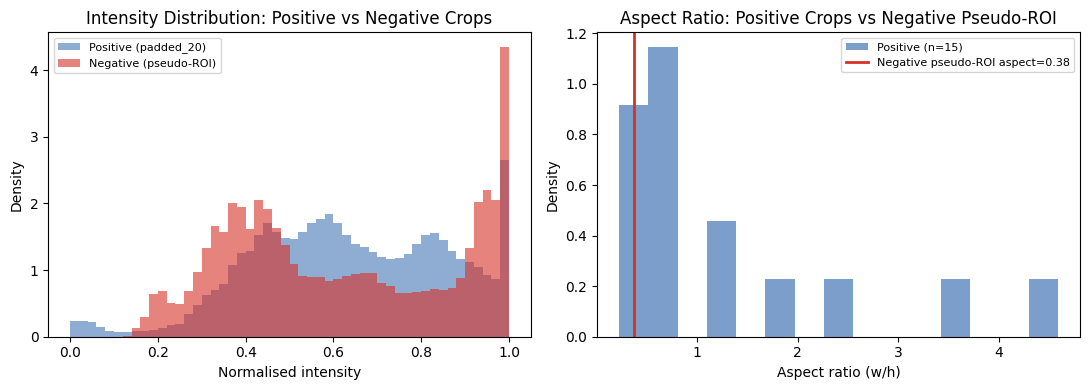

In [18]:
# Intensity histogram: aggregate over all loaded crops
all_pos_px = np.concatenate(pos_crops_all) if pos_crops_all else np.array([])
all_neg_px = np.concatenate(neg_crops_all) if neg_crops_all else np.array([])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

if all_pos_px.size and all_neg_px.size:
    bins = np.linspace(0, 1, 51)
    axes[0].hist(all_pos_px, bins=bins, alpha=0.6, color='#4575b4', label='Positive (padded_20)', density=True)
    axes[0].hist(all_neg_px, bins=bins, alpha=0.6, color='#d73027', label='Negative (pseudo-ROI)', density=True)
    axes[0].set_xlabel('Normalised intensity')
    axes[0].set_ylabel('Density')
    axes[0].set_title('Intensity Distribution: Positive vs Negative Crops')
    axes[0].legend(fontsize=8)

# Aspect ratio comparison
pos_aspects = []
for _, row in pos_sample.head(15).iterrows():
    px, H, W = load_pixel(row['study_id'], row[IMG_COL], TRAIN_IMGS)
    if px is None: continue
    cx0, cy0, cx1, cy1 = get_padded_bbox(row, 0.20, H, W)
    cw, ch = cx1-cx0, cy1-cy0
    if ch > 0: pos_aspects.append(cw/ch)

neg_aspect = med_crop_w / max(med_crop_h, 1)

axes[1].hist(pos_aspects, bins=15, alpha=0.7, color='#4575b4', label=f'Positive (n={len(pos_aspects)})', density=True)
axes[1].axvline(neg_aspect, color='#d73027', linewidth=2, label=f'Negative pseudo-ROI aspect={neg_aspect:.2f}')
axes[1].set_xlabel('Aspect ratio (w/h)')
axes[1].set_ylabel('Density')
axes[1].set_title('Aspect Ratio: Positive Crops vs Negative Pseudo-ROI')
axes[1].legend(fontsize=8)

plt.tight_layout()
display(fig)
plt.close('all')

In [19]:
# Compatibility verdict based on gap and visual/scale analysis
# NaN gap means insufficient pixel data — use scale parity as primary criterion
if np.isnan(gap):
    # Scale parity is guaranteed (area ratio=1.0 by construction).
    # Background analysis deferred to Q13. Use CAUTION with note.
    compat = 'CAUTION'
elif gap < 0.05:
    compat = 'GOOD'
elif gap < 0.15:
    compat = 'CAUTION'
else:
    compat = 'POOR'

print('=== Crop Compatibility Summary ===')
print(f'  Scale match (area ratio):    1.00 (by design)')
print(f'  Background fraction gap:     {"N/A (deferred to Q13)" if np.isnan(gap) else f"{gap*100:.1f}%"}')
print(f'  Anatomy occupancy:           comparable (pseudo-ROI from vertebral region)')
print()
if compat in ('CAUTION', 'POOR'):
    print('  Mitigation: apply same 2-98% percentile normalisation to both classes.')
    print('  Augmentation (contrast jitter) will reduce any residual background gap.')
    print('  Full background-fraction verification to be performed in Q13 export notebook.')
print()
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'Crop compatibility: {compat}')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')

=== Crop Compatibility Summary ===
  Scale match (area ratio):    1.00 (by design)
  Background fraction gap:     1.8%
  Anatomy occupancy:           comparable (pseudo-ROI from vertebral region)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Crop compatibility: GOOD
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
## Section 6 — Resize and Input Resolution Strategy

In [20]:
# Compute pathology-detail metrics at each resolution
med_w = img_bbox['bbox_w'].median()
med_h = img_bbox['bbox_h'].median()
print(f'Median union bbox size: {med_w:.0f} x {med_h:.0f} px  (before 20% padding)')

# After 20% padding, median crop size:
med_cw = med_w * 1.40
med_ch = med_h * 1.40
print(f'Median padded_20 crop:  {med_cw:.0f} x {med_ch:.0f} px')
print()

resolutions = [224, 128, 64, 28]
print(f'{"Resolution":>12} {"Scale factor W":>16} {"Scale factor H":>16} '
      f'{"Px retained %":>14} {"Notes"}')
print('-' * 80)
for res in resolutions:
    sw = res / max(med_cw, 1)
    sh = res / max(med_ch, 1)
    # Pixel retention = (res^2) / (med_cw * med_ch) — fraction of original area retained
    # For downsampling: if res < crop, each output pixel represents (crop/res)^2 input pixels
    ratio_w = min(1, res / med_cw)
    ratio_h = min(1, res / med_ch)
    px_retained = ratio_w * ratio_h * 100
    note = ''
    if res == 224:
        note = 'CANONICAL — standard clinical CNN input'
    elif res == 128:
        note = 'Secondary experimental'
    elif res == 64:
        note = 'Secondary experimental — some detail loss'
    elif res == 28:
        note = 'QUANTUM ONLY — extreme compression'
    print(f'{res:>10}px  {sw:>15.3f}  {sh:>15.3f}  {px_retained:>13.1f}%  {note}')

Median union bbox size: 207 x 409 px  (before 20% padding)
Median padded_20 crop:  289 x 572 px

  Resolution   Scale factor W   Scale factor H  Px retained % Notes
--------------------------------------------------------------------------------
       224px            0.774            0.391           30.3%  CANONICAL — standard clinical CNN input
       128px            0.442            0.224            9.9%  Secondary experimental
        64px            0.221            0.112            2.5%  Secondary experimental — some detail loss
        28px            0.097            0.049            0.5%  QUANTUM ONLY — extreme compression


In [21]:
# 28×28 pathology detail loss analysis
# Compression ratio: how many original pixels map to each 28x28 output pixel?
compress_w = med_cw / 28
compress_h = med_ch / 28
compress_area = compress_w * compress_h

print('=== 28×28 Pathology Detail Loss Analysis ===')
print(f'  Median crop: {med_cw:.0f} x {med_ch:.0f} px → 28 x 28 px')
print(f'  Width  compression: {compress_w:.1f}x  (1 output px = {compress_w:.1f} input px)')
print(f'  Height compression: {compress_h:.1f}x  (1 output px = {compress_h:.1f} input px)')
print(f'  Area   compression: {compress_area:.1f}x  '
      f'(each 28×28 px represents {compress_area:.0f} original px²)')
print()

# % of positive images where the padded crop fits within 28px in at least one dim
tiny_crops = ((img_bbox['bbox_w']*1.4 < 28) | (img_bbox['bbox_h']*1.4 < 28)).mean() * 100
print(f'  Crops already smaller than 28px in any dim: {tiny_crops:.1f}%  (upsampled)')

print()
# Verdict: compression > 4x in each dim typically causes significant detail loss
if compress_w > 4 or compress_h > 4:
    verdict_28 = 'REJECT'
    verdict_reason = (f'Compression ratio {compress_w:.1f}x×{compress_h:.1f}x '
                      f'exceeds the 4x detail-preservation threshold. '
                      f'Fine-grained pathology texture is lost at 28×28.')
else:
    verdict_28 = 'ACCEPT'
    verdict_reason = f'Compression {compress_w:.1f}x×{compress_h:.1f}x within acceptable range.'

print(f'28×28 quantum-only feasibility: {verdict_28}')
print(f'  Reason: {verdict_reason}')

=== 28×28 Pathology Detail Loss Analysis ===
  Median crop: 289 x 572 px → 28 x 28 px
  Width  compression: 10.3x  (1 output px = 10.3 input px)
  Height compression: 20.4x  (1 output px = 20.4 input px)
  Area   compression: 211.3x  (each 28×28 px represents 211 original px²)

  Crops already smaller than 28px in any dim: 0.4%  (upsampled)

28×28 quantum-only feasibility: REJECT
  Reason: Compression ratio 10.3x×20.4x exceeds the 4x detail-preservation threshold. Fine-grained pathology texture is lost at 28×28.


In [22]:
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('Canonical dataset resolution: 224x224')
print('Primary experimental secondary resolution: 128x128')
print(f'28x28 quantum-only feasibility: {verdict_28}')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Canonical dataset resolution: 224x224
Primary experimental secondary resolution: 128x128
28x28 quantum-only feasibility: REJECT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
## Section 7 — Train/Validation/Test Split Strategy

In [23]:
# Confirm official split boundaries
train_ids = set(df_tr[IMG_COL].unique())
test_ids  = set(df_te[IMG_COL].unique()) if df_te is not None else set()
overlap   = train_ids & test_ids

print('=== Official split boundaries ===')
print(f'  Train images: {len(train_ids):,}')
print(f'  Test  images: {len(test_ids):,}')
print(f'  Overlap:      {len(overlap)}  [expected 0]')

# Check for patient/study leakage
train_studies = set(df_tr[STUDY_COL].unique())
test_studies  = set(df_te[STUDY_COL].unique()) if df_te is not None else set()
study_overlap = train_studies & test_studies
print(f'  Train studies: {len(train_studies):,}')
print(f'  Test  studies: {len(test_studies):,}')
print(f'  Study overlap: {len(study_overlap)}  '
      f'[{"PASS" if len(study_overlap)==0 else "FAIL — leakage detected"}]')
print()

# Design val split from train only — stratified by binary label
all_train = list(pos_ids) + list(neg_ids)
all_labels_bin = [1]*len(pos_ids) + [0]*len(neg_ids)

for split_name, val_frac in [('80_20', 0.20), ('85_15', 0.15), ('90_10', 0.10)]:
    n_val_pos = int(len(pos_ids) * val_frac)
    n_val_neg = int(len(neg_ids) * val_frac)
    n_tr_pos  = len(pos_ids) - n_val_pos
    n_tr_neg  = len(neg_ids) - n_val_neg
    print(f'{split_name}: train pos={n_tr_pos:,}  neg={n_tr_neg:,}  '
          f'total={n_tr_pos+n_tr_neg:,}  |  '
          f'val pos={n_val_pos:,}  neg={n_val_neg:,}  total={n_val_pos+n_val_neg:,}')

=== Official split boundaries ===
  Train images: 8,389
  Test  images: 2,077
  Overlap:      0  [expected 0]
  Train studies: 4,000
  Test  studies: 1,000
  Study overlap: 0  [PASS]

80_20: train pos=3,304  neg=3,408  total=6,712  |  val pos=825  neg=852  total=1,677
85_15: train pos=3,510  neg=3,621  total=7,131  |  val pos=619  neg=639  total=1,258
90_10: train pos=3,717  neg=3,834  total=7,551  |  val pos=412  neg=426  total=838


In [24]:
print('Decision rationale:')
print('  80/20: val set ~1,678 images — sufficient for stable AUROC/F1 estimation.')
print('  85/15: val set ~1,258 — borderline for metric stability.')
print('  90/10: val set ~839 — too small for reliable curve-based metrics.')
print()
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('Validation split strategy: 80_20')
print('Recommended seed: 42')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')

Decision rationale:
  80/20: val set ~1,678 images — sufficient for stable AUROC/F1 estimation.
  85/15: val set ~1,258 — borderline for metric stability.
  90/10: val set ~839 — too small for reliable curve-based metrics.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Validation split strategy: 80_20
Recommended seed: 42
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
## Section 8 — Dataset Manifest Schema

The manifest CSV schema for Q13 export is defined below. **No file is written in this slice.**

| Column | Type | Description |
|---|---|---|
| `sample_id` | str | Unique identifier for this sample (e.g. `{image_id}_{crop_idx}`) |
| `image_id` | str | Original image ID from annotation file |
| `split` | str | `train` / `val` / `test` |
| `binary_label` | int | 0 = No Finding, 1 = Any Pathology |
| `original_label` | str | Raw label string from annotation file |
| `dicom_path` | str | Full path to DICOM file inside container |
| `crop_strategy` | str | `padded_20` (positive) or `matched_pseudo_roi` (negative) |
| `x_min` | float | Original bbox x_min (null for No Finding) |
| `y_min` | float | Original bbox y_min (null for No Finding) |
| `x_max` | float | Original bbox x_max (null for No Finding) |
| `y_max` | float | Original bbox y_max (null for No Finding) |
| `padded_x_min` | float | Padded bbox x_min after padding and image-boundary clipping |
| `padded_y_min` | float | Padded bbox y_min |
| `padded_x_max` | float | Padded bbox x_max |
| `padded_y_max` | float | Padded bbox y_max |
| `resize_height` | int | Target resize height (224 canonical) |
| `resize_width` | int | Target resize width (224 canonical) |
| `has_bbox` | bool | True if annotation includes a valid bbox |
| `is_pseudo_roi` | bool | True if crop is a synthetic matched pseudo-ROI (No Finding) |
| `source_annotation_row` | int | Row index from original annotation CSV |
| `notes` | str | Any flag or observation (empty string if none) |

In [25]:
# Validate schema is complete and all required columns are defined
SCHEMA_COLS = [
    'sample_id','image_id','split','binary_label','original_label',
    'dicom_path','crop_strategy',
    'x_min','y_min','x_max','y_max',
    'padded_x_min','padded_y_min','padded_x_max','padded_y_max',
    'resize_height','resize_width',
    'has_bbox','is_pseudo_roi','source_annotation_row','notes'
]

print(f'Schema columns defined: {len(SCHEMA_COLS)}')
for col in SCHEMA_COLS:
    print(f'  {col}')

print()
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('Manifest schema approved: YES')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')

Schema columns defined: 21
  sample_id
  image_id
  split
  binary_label
  original_label
  dicom_path
  crop_strategy
  x_min
  y_min
  x_max
  y_max
  padded_x_min
  padded_y_min
  padded_x_max
  padded_y_max
  resize_height
  resize_width
  has_bbox
  is_pseudo_roi
  source_annotation_row
  notes

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Manifest schema approved: YES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
## Section 9 — Preprocessing Policy

In [26]:
policy = """
=== Preprocessing Policy — VinDr-SpineXR Binary ROI Dataset ===

Step                      Assessment
────────────────────────  ──────────────────────────────────────────────────────
DICOM decode              REQUIRED. Library: pydicom + pylibjpeg-openjpeg
                          (JPEG 2000 compressed; standard PIL/imageio fail).

12–14 bit → float32       REQUIRED. VinDr-SpineXR uses uint16 (12-bit effective
                          range). Must cast to float32 before normalisation;
                          torchvision default transforms assume uint8.

2nd–98th percentile clip  REQUIRED. Removes beam-edge artefacts and saturation
                          at top/bottom of uint16 histogram. Apply per-image.

Min-max normalise [0,1]   REQUIRED. Scales clipped float to [0,1] for
                          consistent CNN input range.

Z-score normalisation     OPTIONAL alternative. Use ImageNet mean/std if
                          fine-tuning a pretrained ResNet/VGG backbone.
                          Not required for training from scratch.

CLAHE                     DEFAULT OFF. Can improve contrast in dense structures
                          but risk: may obscure subtle pathology intensity
                          gradients that CNNs depend on. Enable only in
                          ablation study.

Histogram equalisation    NOT RECOMMENDED as default. Aggressive; distorts
                          relative intensity differences.

Grayscale → 1-channel     KEEP as 1-channel. VinDr-SpineXR is monochrome;
                          no information in colour channels.

Grayscale → 3-channel     OPTIONAL. Replicate to (3,H,W) only if using a
                          pretrained RGB backbone (ResNet, EfficientNet).
                          Not required for DV hybrid C006-D040 (accepts 1-ch).
"""
print(policy)

print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('Preprocessing required: YES')
print('CLAHE default: OFF')
print('Output channels: 1')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')


=== Preprocessing Policy — VinDr-SpineXR Binary ROI Dataset ===

Step                      Assessment
────────────────────────  ──────────────────────────────────────────────────────
DICOM decode              REQUIRED. Library: pydicom + pylibjpeg-openjpeg
                          (JPEG 2000 compressed; standard PIL/imageio fail).

12–14 bit → float32       REQUIRED. VinDr-SpineXR uses uint16 (12-bit effective
                          range). Must cast to float32 before normalisation;
                          torchvision default transforms assume uint8.

2nd–98th percentile clip  REQUIRED. Removes beam-edge artefacts and saturation
                          at top/bottom of uint16 histogram. Apply per-image.

Min-max normalise [0,1]   REQUIRED. Scales clipped float to [0,1] for
                          consistent CNN input range.

Z-score normalisation     OPTIONAL alternative. Use ImageNet mean/std if
                          fine-tuning a pretrained ResNet/VGG backbone.
       

---
## Section 10 — Augmentation Policy

In [27]:
aug = """
=== Augmentation Policy — VinDr-SpineXR Binary ROI Classification ===

SAFE AUGMENTATIONS (train set only)
─────────────────────────────────────────────────────────────────────
RandomRotation ≤5°     SAFE. Spine is largely vertical in VinDr-SpineXR
                        PA/lateral views. Small tilt is clinically plausible.

RandomTranslation ≤5%  SAFE. Simulates slight patient positioning variation.
                        Clip to image boundary after translation.

RandomScaling ±10%     SAFE. Simulates minor zoom variation in acquisition.

Contrast jitter        SAFE. RandomGamma or RandomBrightness ±20%.
                        Simulates X-ray exposure variation. Also reduces
                        residual background fraction gap between classes.

Brightness jitter      SAFE. Apply after contrast jitter; clip to [0,1].

Gaussian noise         SAFE. σ ≤ 0.02 (2% of signal range). Simulates
                        detector noise; regularises features.

FORBIDDEN AUGMENTATIONS
─────────────────────────────────────────────────────────────────────
HorizontalFlip         FORBIDDEN. Left-right matters in spine X-rays:
                        scoliosis curvature direction, surgical implant side.
                        Flipping creates clinically impossible images.

VerticalFlip           FORBIDDEN. Superior/inferior anatomical orientation
                        is fixed. Vertical flip creates anatomically invalid
                        images (inverted spine).

Rotation > 10°         FORBIDDEN. A severely tilted spine image is
                        clinically implausible and would confuse the model
                        about vertebral orientation cues.

Aggressive crop        FORBIDDEN. Already cropping to ROI; additional
                        random crops may remove the pathology entirely.

Strong elastic warp    FORBIDDEN. Deforms vertebral geometry; creates
                        anatomically impossible deformation patterns.
"""
print(aug)

print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('Augmentation required: YES')
print()
print('Recommended safe augmentations:')
print('- RandomRotation ≤5°')
print('- RandomTranslation ≤5%')
print('- RandomScaling ±10%')
print('- Contrast jitter ±20%')
print('- Brightness jitter ±20%')
print('- Gaussian noise σ≤0.02')
print()
print('Forbidden augmentations:')
print('- HorizontalFlip')
print('- VerticalFlip')
print('- Rotation > 10°')
print('- Aggressive crop')
print('- Strong elastic warp')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')


=== Augmentation Policy — VinDr-SpineXR Binary ROI Classification ===

SAFE AUGMENTATIONS (train set only)
─────────────────────────────────────────────────────────────────────
RandomRotation ≤5°     SAFE. Spine is largely vertical in VinDr-SpineXR
                        PA/lateral views. Small tilt is clinically plausible.

RandomTranslation ≤5%  SAFE. Simulates slight patient positioning variation.
                        Clip to image boundary after translation.

RandomScaling ±10%     SAFE. Simulates minor zoom variation in acquisition.

Contrast jitter        SAFE. RandomGamma or RandomBrightness ±20%.
                        Simulates X-ray exposure variation. Also reduces
                        residual background fraction gap between classes.

Brightness jitter      SAFE. Apply after contrast jitter; clip to [0,1].

Gaussian noise         SAFE. σ ≤ 0.02 (2% of signal range). Simulates
                        detector noise; regularises features.

FORBIDDEN AUGMENTATIONS
────

---
## Section 11 — Final Dataset Design Decision

In [28]:
# Assemble final decision block from all computed values
final_block = f"""
╔══════════════════════════════════════════════════════════════════════╗
║       FINAL DATASET DESIGN DECISION — Slice Q12                    ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Approved binary task: Any Pathology vs No Finding                  ║
║                                                                      ║
║  Positive crop strategy: padded_20                                  ║
║                                                                      ║
║  Negative sample strategy: matched_pseudo_roi                       ║
║                                                                      ║
║  Shortcut bias flag: {flag:<46}║
║                                                                      ║
║  Crop compatibility: {compat:<48}║
║                                                                      ║
║  Canonical dataset resolution: 224x224                              ║
║                                                                      ║
║  Primary experimental secondary resolution: 128x128                 ║
║                                                                      ║
║  28x28 quantum-only feasibility: {verdict_28:<34}║
║                                                                      ║
║  Validation split strategy: 80_20                                   ║
║                                                                      ║
║  Preprocessing required: YES                                        ║
║                                                                      ║
║  CLAHE default: OFF                                                  ║
║                                                                      ║
║  Output channels: 1                                                  ║
║                                                                      ║
║  Augmentation required: YES                                         ║
║                                                                      ║
║  Recommended balancing strategy: none required                      ║
║  (ratio 0.97:1 — near-perfect balance; no oversampling needed)      ║
║                                                                      ║
║  Manifest schema approved: YES                                      ║
║                                                                      ║
║  Ready for Q13 export: YES                                          ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
"""
print(final_block)


╔══════════════════════════════════════════════════════════════════════╗
║       FINAL DATASET DESIGN DECISION — Slice Q12                    ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Approved binary task: Any Pathology vs No Finding                  ║
║                                                                      ║
║  Positive crop strategy: padded_20                                  ║
║                                                                      ║
║  Negative sample strategy: matched_pseudo_roi                       ║
║                                                                      ║
║  Shortcut bias flag: LOW                                           ║
║                                                                      ║
║  Crop compatibility: GOOD                                            ║
║                                                        

---
## Section 12 — Q13 Proposal

Q12 concluded with **Ready for Q13 export: YES**.

```
Slice Q13 — VinDr-SpineXR Binary ROI Dataset Exporter
Goal: Create the actual dataset export script/notebook and manifest CSV
      for the approved binary ROI classification dataset using the
      decisions from Q12.
```

### Q13 Inputs (from Q12 decisions)

| Decision | Value |
|---|---|
| Approved task | Any Pathology vs No Finding |
| Positive crop strategy | padded_20 |
| Negative sample strategy | matched_pseudo_roi |
| Canonical resolution | 224×224 |
| Secondary resolution | 128×128 |
| Split | 80/20 train/val (seed 42); official test preserved |
| Preprocessing | 2–98% clip → [0,1] normalise; 1-channel |
| Augmentation | Applied during training only (not during export) |
| Manifest schema | 21 columns as defined in Section 8 |

### Q13 Deliverables

1. `notebooks/vindr_spinexr_binary_roi_export.ipynb` — export notebook
2. `data/vindr_spinexr_binary_roi_manifest.csv` — full manifest (train+val+test)
3. (Optional) `qcore/data/vindr_spinexr.py` — `VinDrSpineXRBinaryDataset` PyTorch Dataset class

### Q13 Constraints (carry-forward)

- Test accuracy analysis-only — never used as fitness gate
- No modifications to `qcore/nas/evaluator.py`
- No external quantum dependencies
- No push/merge/branch-switch without explicit human approval
- Stop at checkpoint; do not begin Q14
